# Поиска инсайтов и точек роста сервиса доставки еды

Необходимо найти ответы на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

- изучить пользовательский путь и проанализировать конверсии через воронки;
- сегментация пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризация ресторанов методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.


### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

Загрузим данные и получим первую информацию о них. Проведем необходимую предобработку.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/insides_data.csv', parse_dates = ['first_date', 'datetime'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

In [4]:
df.head()

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN


In [5]:
if df.duplicated().sum() > 0:
    print('Есть дубли!')
else:
    print('Дублей нет')

Дублей нет


Поменяем разрядность, чтобы датасет занимал меньше места:

In [6]:
for col in df[['object_id', 'order_id', 'revenue', 'delivery', 'commission']]:
    df[col] = pd.to_numeric(df[col], downcast = 'float')

In [7]:
non_int_values = df[df['user_id'] % 1 != 0]['user_id']

if non_int_values.empty:
    print('Все user_id целые числа')
else:
    print('Найдены user_id с дробной частью:')
    print(f'Количество: {len(non_int_values)}')

Все user_id целые числа


In [8]:
for column in df[['user_id', 'city_id', 'visit_id']]:
    df[column] = df[column].astype('int32')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  int32         
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int32         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int32         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float32       
 11  order_id      7008 non-null    float32       
 12  revenue       7008 non-null    float32       
 13  delivery      7008 non-null    float32       
 14  commission    21308 non-null   float32       
dtypes: datetime64[ns]

**Итог раздела №1:**

* Датасет содержит 205 510 строк;
* Есть пропуски в некоторых столбцах, но их можно называть естественными, т.к. столбец 'event' содержит информацию не только о заказе, но и другие события;
* Дублей в данных нет;
* Поменяли разрядность у числовых данных.

---

## 2. Анализ пользовательского пути


Построим и визуализируем общую воронку (по всем данным).
    
Будет две воронки: 
- **классическую воронку**-  доля от первого шага в процентах
- **step-by-step** - с конверсией от предыдущего этапа.

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [10]:
df['event'].unique()

array(['authorization', 'reg_page', 'confirm_phone', 'login', 'main_page',
       'object_page', 'add_to_cart', 'order'], dtype=object)

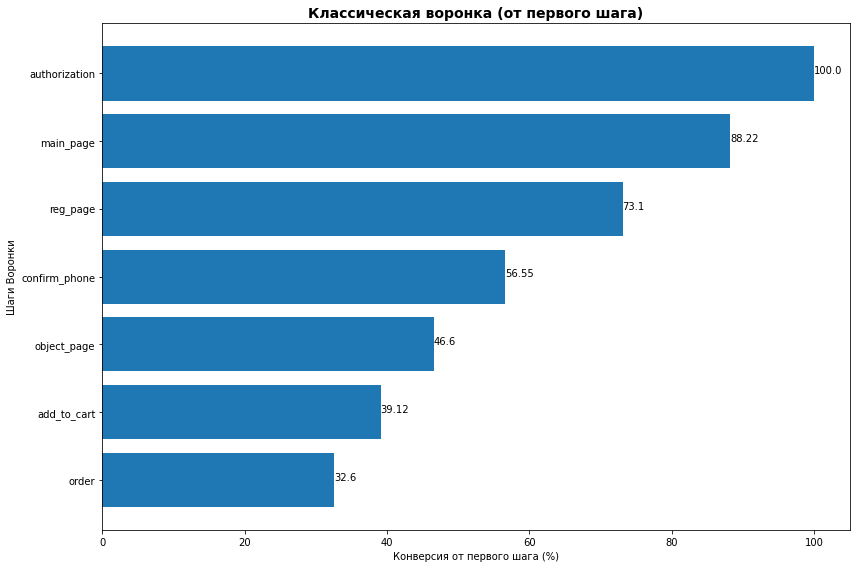

In [11]:
# классическая воронка

steps = ['authorization', 'main_page','reg_page', 'confirm_phone', 'object_page', 'add_to_cart', 'order'] # шаги, которые проходит ползователь

df_steps = df[df['event'].isin(steps)]

funnel = df_steps.groupby('event').agg(cnt_users = ('user_id', 'nunique')).reindex(steps).reset_index()

funnel['classic_cr'] = round(funnel['cnt_users'] / funnel['cnt_users'].iloc[0] * 100, 2)

funnel_classic = funnel.sort_values(by = 'cnt_users', ascending = True)

plt.figure(figsize = (12, 8))

plt.barh(funnel_classic['event'],
        funnel_classic['classic_cr'])


plt.title('Классическая воронка (от первого шага)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Конверсия от первого шага (%)')
plt.ylabel('Шаги Воронки')

for i, value in enumerate(funnel_classic['classic_cr']):
    plt.text(value, i, str(value))
    
plt.tight_layout()

plt.show()

На данном этапе анализа воронки можно сказать, что аномалий в воронке не видно, каждый этап убывает плавно, без серьезных перепадов между шагами.

Возможно, что воронка step by step позволит увидеть какие-то особенности.

In [12]:
funnel['step_by_step_CR'] = round(funnel['cnt_users'] / funnel['cnt_users'].shift(1) * 100, 2)
funnel

,event,cnt_users,classic_cr,step_by_step_CR
0,authorization,7410,100.00,NaN
1,main_page,6537,88.22,88.22
2,reg_page,5417,73.10,82.87
3,confirm_phone,4190,56.55,77.35
4,object_page,3453,46.60,82.41
5,add_to_cart,2899,39.12,83.96
6,order,2416,32.60,83.34


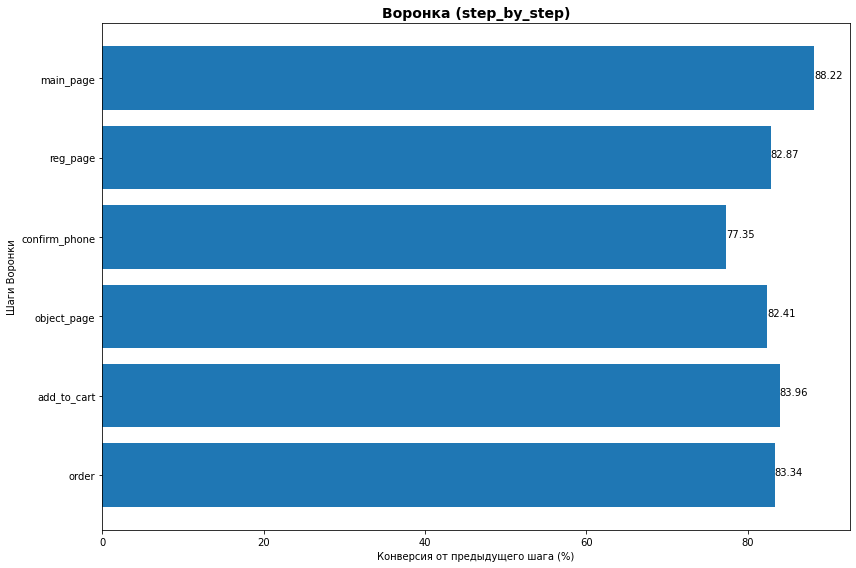

In [13]:
# строим воронку по CR ctep by step

funnel_step = funnel.sort_values(by ='cnt_users', ascending = True)

funnel_step = funnel_step.dropna(subset = ['step_by_step_CR']) # удялаем первую строчку талбицы, чтобы график корректно отображался

plt.figure(figsize = (12, 8))

plt.barh(funnel_step['event'],
        funnel_step['step_by_step_CR'])

for i, value in enumerate(funnel_step['step_by_step_CR']):
    plt.text(value, i, str(value))

   

plt.title('Воронка (step_by_step)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Конверсия от предыдущего шага (%)')
plt.ylabel('Шаги Воронки')

plt.tight_layout()

plt.show()

В среднем на каждом шаге теряется 12–17% относительно предыдущего, больше всего теряется на шаге `confirm_phone` (более 22%).

Как раз прошлое обновление касалось именно этого шага. Пока рано делать какие-то предположения и выводы, но стоит обращать внимание на этот шаг в дальнейшем исследовании.

Сравните пользовательский путь в двух приложениях: в мобильной версии и десктопной.

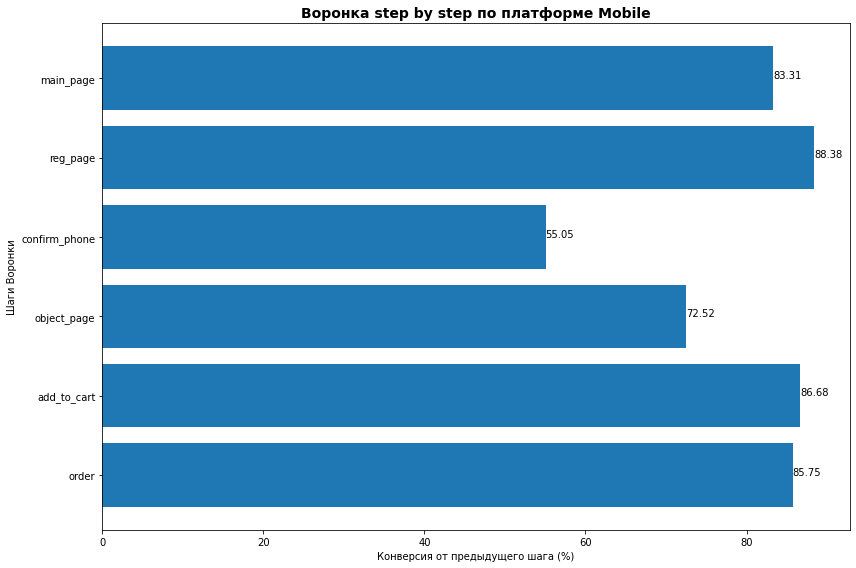

In [14]:
df_mobile = df[df['device_type'] == 'Mobile']

df_mobile = df_mobile[df_mobile['event'].isin(steps)]

mobile_funnel = df_mobile.groupby('event').agg(cnt_users = ('user_id', 'nunique')).reindex(steps).reset_index()

mobile_funnel['step_by_step_cr'] = round(mobile_funnel['cnt_users'] / mobile_funnel['cnt_users'].shift(1) * 100, 2)

mobile_funnel = mobile_funnel.dropna(subset = ['step_by_step_cr'])

mobile_funnel = mobile_funnel.sort_values(by = 'cnt_users', ascending = True)

plt.figure(figsize = (12, 8))

plt.barh(mobile_funnel['event'],
        mobile_funnel['step_by_step_cr'])

for i, value in enumerate(mobile_funnel['step_by_step_cr']):
    plt.text(value, i, str(value))
    
plt.title('Воронка step by step по платформе Mobile', fontsize = 14, fontweight = 'bold')
plt.xlabel('Конверсия от предыдущего шага (%)')
plt.ylabel('Шаги Воронки')

plt.tight_layout()

plt.show()

На этой диаграмме уже видно, что существенная потеря пользователей идет на шагах: `confirm_phone` и `object_page`, 45% и 27% соответственно. Когда на других шагах потери составляют 12–16%.

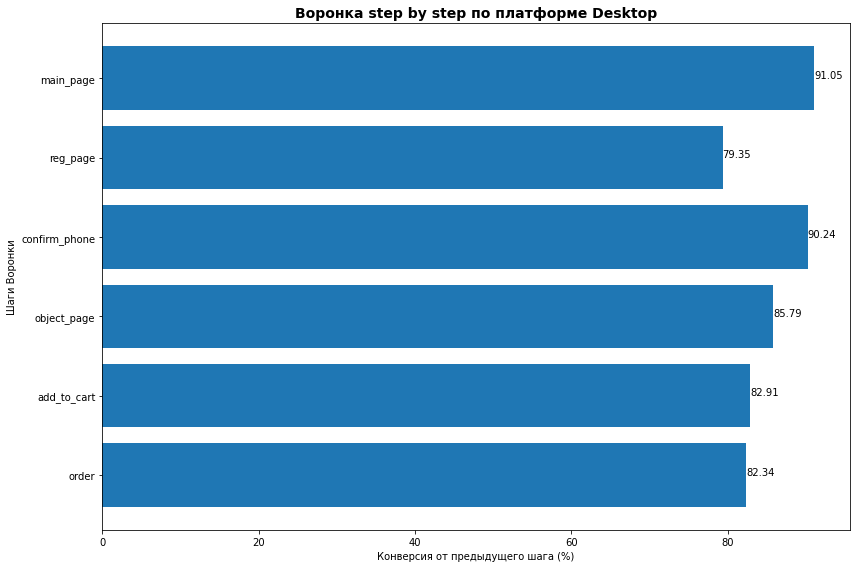

In [15]:
df_desktop = df[df['device_type'] == 'Desktop']

df_desktop = df_desktop[df_desktop['event'].isin(steps)]

desktop_funnel = df_desktop.groupby('event').agg(cnt_users = ('user_id', 'nunique')).reindex(steps).reset_index()
desktop_funnel['step_by_step_cr'] = round(desktop_funnel['cnt_users'] / desktop_funnel['cnt_users'].shift(1) * 100, 2)

desktop_funnel = desktop_funnel.sort_values(by = 'cnt_users', ascending = True)

desktop_funnel = desktop_funnel.dropna(subset =['step_by_step_cr'])

plt.figure(figsize = (12, 8))

plt.barh(desktop_funnel['event'],
        desktop_funnel['step_by_step_cr'])

plt.title('Воронка step by step по платформе Desktop', fontsize = 14, fontweight = 'bold')
plt.xlabel('Конверсия от предыдущего шага (%)')
plt.ylabel('Шаги Воронки')

for i, v in enumerate(desktop_funnel['step_by_step_cr']):
    plt.text(v, i, str(v))

plt.tight_layout()

plt.show()

Воронка по desktop не показывает таких сильных просадок на каком-либо шаге. Потери составляют от 10% до 20%.

**Итог раздела №2:**

* Классическая воронка по всем данным не показывает каких-либо явных проблем.
* В воронке step by step уже начинает вырисовываться проблемное место - `confirm_phone`.
* Анализ в разрезе платформ (Desktop, Mobile) выявил зону роста более явно.
* На платформе desktop существенных проблем нет.
* Платформа Mobile больше всего теряет клиентов на шагах `confirm_phone`  и `object_page`
* Стоит обратить внимание, что на последних шагах (add_to_cart и order) у десктопной версии конверсия пониже, чем у мобильной, что может говорить о тех. проблемах при оформлении заказа или неудобстве интерфейса.

В последнем обновлении мобильного приложения как раз меняли алгоритм подтверждения мобильного телефона.

---

## 3. RFM сегментация

Сегментируем пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

В качестве даты анализа установим **03 июля 2021 года**.

In [16]:
# print(f"минимальная дата: {df['datetime'].min()}")
# print(f"максимальная дата: {df['datetime'].max()}")

Так как в `revenue` указывается стоимость заказа, т. е. сюда входят деньги, которые получает ресторан, то отдельно посчитаем прибыль (`profit`), которую получает сервис, это поле будет использоваться для подсчета `monetary`.

In [17]:
# из датасета отбираем только события с окупками / оформлением заказа
df_order = df[df['event'] == 'order'].copy()

df_order['order_renecy'] = pd.to_datetime('2021-07-03') - df_order['datetime']

df_order['profit'] = round(df_order['revenue'] * df_order['commission'], 2) 
# df_order
df_rfm = df_order.groupby('user_id').agg(renecy = ('order_renecy', lambda x: x.min().days),
                                         frequency = ('order_id', 'count'),
                                         monetary = ('profit', 'sum')).reset_index()

display(df_rfm.head())

,user_id,renecy,frequency,monetary
0,5506,32,2,187.600006
1,6291,57,1,122.500000
2,6820,41,1,63.009998
3,11062,57,1,189.279999
4,13254,54,1,27.650000


Собрали датафрейм, где:

* `renecy` - кол-во дней с последнего заказа;
* `frequency` - частота покупок;
* `monetary` - сумма денег, которую принес пользователь за все свои покупки.

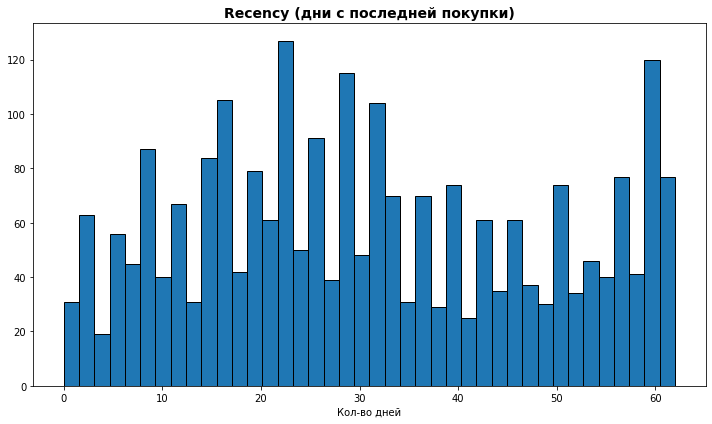

In [18]:
plt.figure(figsize = (10, 6))

plt.hist(df_rfm['renecy'],
        bins = 40,
        edgecolor = 'black')

plt.title('Recency (дни с последней покупки)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Кол-во дней')

                      
plt.tight_layout()
                      
plt.show()

Гистограмма по Renency имеет множество пиков, т. е. нельзя сказать, что основная масса пользователей покупала n дней назад, тут логичнее будет поделить сегменты на 3 равных интервала.

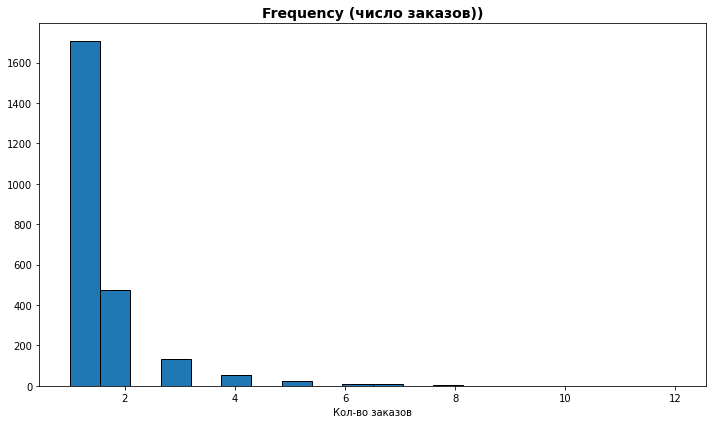

In [19]:
plt.figure(figsize = (10, 6))

plt.hist(df_rfm['frequency'],
        bins = 20,
        edgecolor = 'black')

plt.title('Frequency (число заказов))', fontsize = 14, fontweight = 'bold')
plt.xlabel('Кол-во заказов')

                      
plt.tight_layout()
                      
plt.show()

Гистограмма по Frequency говорит о том, что в основном пользователи совершает по 1 заказу, и чем больше кол-во заказов, тем меньше их частота.

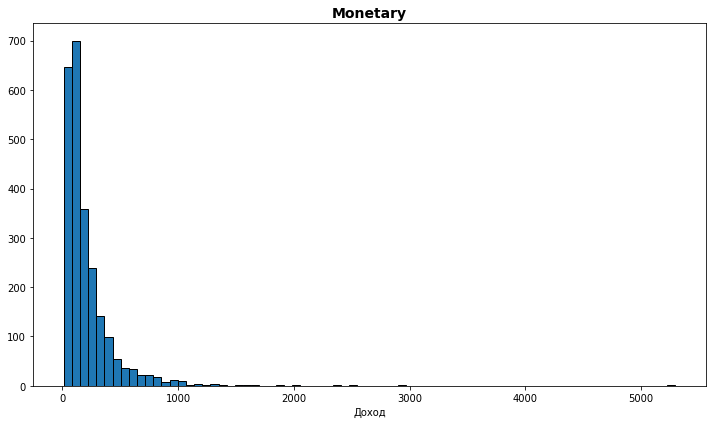

In [20]:
plt.figure(figsize = (10, 6))

plt.hist(df_rfm['monetary'],
        bins = 75,
        edgecolor = 'black')

plt.title('Monetary', fontsize = 14, fontweight = 'bold')
plt.xlabel('Доход')

                      
plt.tight_layout()
                      
plt.show()

Гистограмма по Monetary тоже смещена влево. Т. е. большинство пользователей принесли сервису небольшую комиссию, что логично вытекает из того, что пользователи в основном заказывали 1 раз.

Выделим **RFM-сегменты** и изучим распределение пользователей по ним.
    
Применим следующие подходы к выделению RFM сегментов:
- **Recency** - разделим на три равные группы.
- **Frequency** -  разделим на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** - разделите на три группы по 33-му и 66-му перцентилям.

In [21]:
df_rfm['r'] = pd.cut(df_rfm['renecy'], bins = 3, labels = [3, 2, 1])

df_rfm['f'] = pd.cut(df_rfm['frequency'], bins = [0, 1, 2, float('inf')], labels = [1, 2, 3])

df_rfm['m'] = pd.qcut(df_rfm['monetary'], q = 3, labels = [1, 2, 3])

df_rfm[['r', 'f', 'm']] = df_rfm[['r', 'f', 'm']].astype('str')
df_rfm['rfm'] = df_rfm['r'] + df_rfm['f'] + df_rfm['m']

df_rfm.head()


,user_id,renecy,frequency,monetary,r,f,m,rfm
0,5506,32,2,187.600006,2,2,2,222
1,6291,57,1,122.500000,1,1,2,112
2,6820,41,1,63.009998,2,1,1,211
3,11062,57,1,189.279999,1,1,2,112
4,13254,54,1,27.650000,1,1,1,111


In [22]:
rfm = df_rfm.groupby('rfm')['user_id'].nunique().reset_index()
rfm['share'] = round(rfm['user_id'] / rfm['user_id'].sum() * 100, 2)
rfm = rfm.sort_values(by = 'user_id', ascending = False)
rfm

,rfm,user_id,share
8,211,279,11.55
0,111,255,10.55
16,311,244,10.10
9,212,230,9.52
1,112,196,8.11
17,312,194,8.03
10,213,131,5.42
13,223,113,4.68
15,233,103,4.26
18,313,93,3.85


**Итог раздела №2:**

* Почти треть всех пользователей - это пользователи, которые покупают нечасто и приносят мало денег.
* В тройку лидеров по численности входит также сегмент 111 - пользователи, которые давно не делали покупок.

Для этих групп следует разработать предложения, которые будут их стимулировать возвращаться в продукт и чаще совершать покупки.

* Лояльные пользователи (333, 233, 313, 323, 322, 232, 332, 133) их приблизительно 18%.

Для таких пользователей надо разработать персонализированные предложения, программы лояльности и акции, чтобы их удерживать в продукте и растить метрики RFM, т.к. у некоторых сегментов есть потенциал роста.
* сегменты, которые давно не делали покупок (112, 113, 121, 122, 123), их тоже почти 18%.

Стоит разработаться специальное предложение, чтобы их вернуть. 

---

## 4. K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, проведем кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

Подготовим данные для кластеризации и для каждого ресторана:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

In [23]:
# df.head()

In [24]:
df_rest = df.groupby('rest_id').agg(cnt_orders = ('order_id', 'count'),
                                   avg_price = ('revenue', 'mean'),
                                   cnt_object = ('object_id', 'nunique'))


df_rest.head()

,cnt_orders,avg_price,cnt_object
rest_id,,,
1be5a933aab34fbab594bebba48e976e,290,2385.645020,46
1d6bb74687104fa1953924c9684fe624,204,2984.793213,37
2c6095730b514c189ee41c65f03febc3,15,2050.570557,10
3247a3b5f9494812a3c1a73c5b61f004,68,2694.695312,4
39b7eab4f4704ed2886fafe171489960,68,2019.813354,11


Нормализуеv данные и найдите оптимальное количество кластеров.

In [25]:
df_rest['avg_price'] = round(df_rest['avg_price'], 2)

In [26]:

from sklearn.preprocessing import StandardScaler

# Создаем объект масштабировщика
scaler = StandardScaler()

# Обучаем и трансформируем наши признаки
df_kmeans_scaled = scaler.fit_transform(df_rest)


In [27]:
#df_kmeans_scaled

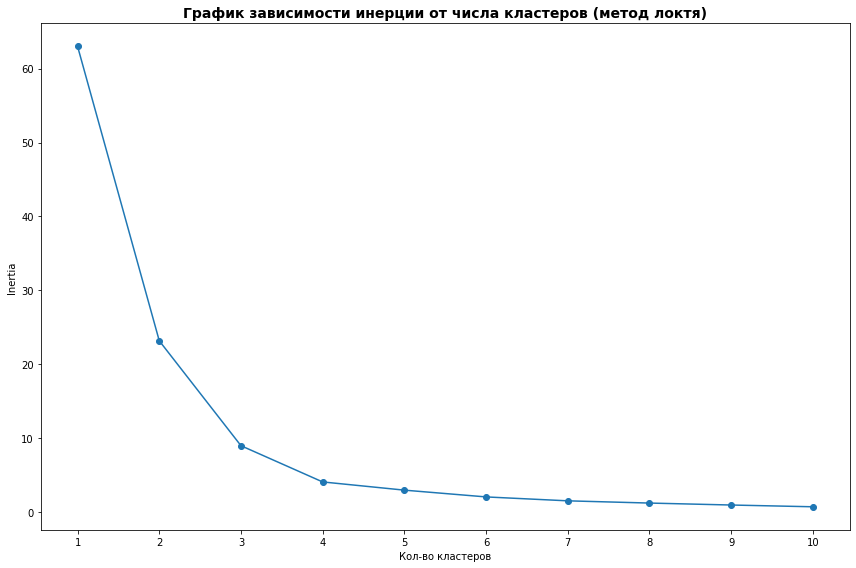

In [28]:

from sklearn.cluster import KMeans

df_kmeans = df_rest[['cnt_orders', 'avg_price', 'cnt_object']] # df_kmeans

inertia = []

min_k = 1
max_k = 10

for k in range(min_k, max_k + 1):
    km = KMeans(n_clusters = k)
    km.fit_transform(df_kmeans_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize = (12, 8))

plt.plot(range(min_k, max_k + 1),
        inertia,
        marker = 'o')

plt.title('График зависимости инерции от числа кластеров (метод локтя)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Кол-во кластеров')
plt.ylabel('Inertia')

plt.xticks(range(min_k, max_k + 1))

plt.tight_layout()

plt.show()


В качестве оптимального количества кластеров можно выбрать 4 кластера, т.к. начиная именно с 4-х кластеров инерция хоть и снижается, но снижается намного плавнее, чем было до.

Проведем кластеризацию, проанализируем полученные результаты и рассчитаем средние значения по каждому кластеру.

In [29]:
kmeans = KMeans(n_clusters = 4)
labels = kmeans.fit_predict(df_kmeans_scaled)

centrouds = kmeans.cluster_centers_


In [30]:
labels

array([2, 2, 0, 2, 0, 2, 2, 2, 1, 3, 0, 0, 0, 0, 0, 3, 1, 2, 0, 2, 0],
      dtype=int32)

In [31]:
df_kmeans_scaled = pd.DataFrame(scaler.fit_transform(df_kmeans), 
                                columns=df_kmeans.columns, 
                                index=df_kmeans.index)

In [32]:
df_kmeans_scaled

,cnt_orders,avg_price,cnt_object
rest_id,,,
1be5a933aab34fbab594bebba48e976e,-0.072088,-0.202602,0.387545
1d6bb74687104fa1953924c9684fe624,-0.213907,0.484813,0.185765
2c6095730b514c189ee41c65f03febc3,-0.525581,-0.587033,-0.419573
3247a3b5f9494812a3c1a73c5b61f004,-0.438180,0.151988,-0.554093
39b7eab4f4704ed2886fafe171489960,-0.438180,-0.622325,-0.397153
43e40bacafe8409bb5592877a42d737e,-0.403550,0.814219,-0.419573
4a693ca500b44ba499f92a724aec5f17,-0.166084,0.567489,-0.195374
4b9cde3378c447ed81c2c6d4854d4f7e,-0.527230,0.013507,-0.397153
55d4027ac83e438f9f893892f6903409,2.734621,0.130567,2.920997


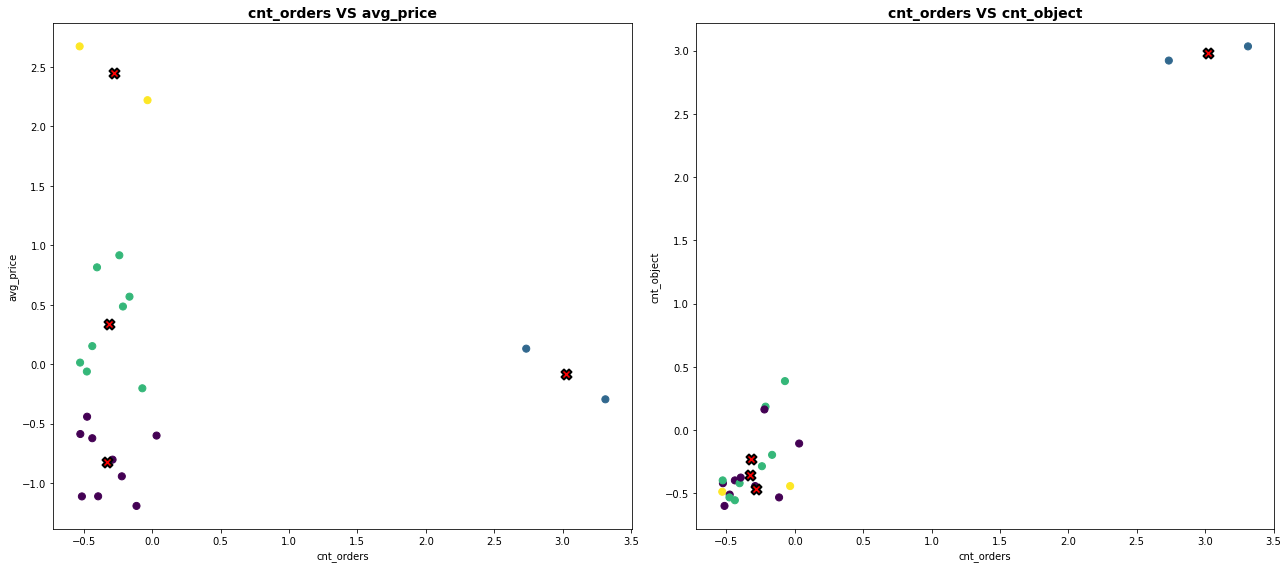

In [33]:
fig, axes = plt.subplots(1, 2, figsize = (18, 8))

axs = ['cnt_orders', 'avg_price', 'cnt_object']

for i, (x_idx, y_idx) in enumerate([[0, 1], [0, 2]]):
    x_label = axs[x_idx]
    y_label = axs[y_idx]
    
    axes[i].scatter(df_kmeans_scaled[x_label],
                   df_kmeans_scaled[y_label],
                   c = labels,
                    cmap = 'viridis',
                    s = 50)
    
    axes[i].scatter(centrouds[:, x_idx],
                   centrouds[:, y_idx],
                   s = 100,
                   c = 'red',
                   edgecolors = 'black',
                   linewidths = 2,
                   marker = 'X')
    
    axes[i].set_title(f'{x_label} VS {y_label}', fontsize = 14, fontweight = 'bold')
    axes[i].set_xlabel(x_label)
    axes[i].set_ylabel(y_label)
    
    
plt.tight_layout()

plt.show()

1. *Средний чек в зависимости от количества заказов.* Тут кластеры достаточно разрознены и хорошо отличимы.
2. *Количество блюд в зависимости от количества заказов.* Тут сильно выделяется кластер с большим ассортиментом и большим кол-вом заказов. Другие кластеры находятся слишком плотно.

Посмотрим на таблицу со средними значениями по кластерам:

In [34]:
# Добавляем столбец с кластером в таблицу к ресторанам
rest = df_rest.copy().reset_index()
rest['cluster'] = labels 

# Считаем средние и количество
cluster_stats = rest.groupby('cluster').agg({
    'cnt_orders': 'mean',
    'avg_price': 'mean',
    'cnt_object': 'mean',
    'rest_id': 'count' 
}).rename(columns={'rest_id': 'n_restaurants'})


cluster_stats.index = [f'Кластер №{i+1}' for i in cluster_stats.index]

display(cluster_stats)

,cnt_orders,avg_price,cnt_object,n_restaurants
Кластер №1,135.333333,1844.666626,12.777778,9
Кластер №2,2167.500000,2490.469971,161.500000,2
Кластер №3,141.250000,2854.574951,18.625000,8
Кластер №4,162.500000,4693.620117,8.000000,2


*Кластер №1:* 
Средний кластер по всем метрикам. 
Стоит обсудить с ресторанами условия акций или программ лояльности, которые бы увеличили кол-во заказов.

*Кластер №2:*
Самый активный и популярный. Кратное превосходство по количеству заказов и ассортименту. 
И достаточно гуманный средний чек. 
С такими ресторанами надо поддерживать отношения, стоит подумать над индивидуальными условиями работы, чтобы удерживать эти рестораны в сервисе. 
 можно предложить  ввести в ассортимент новые блюда, более маржинальные, или, может, заменить менее маржинальные блюда.
  
*Кластер №3:*
сюда попали рестораны с маленьким ассортиментом, самым большим чеком и с достаточно хорошим кол-вом заказов. Даже с таким чеком у этих ресторанов больше заказов, чем у ресторанов из кластера 1 и 4. Тут стоит договориться с ресторанами о расширении ассортимента, и расширении за счет не очень дорогих блюд. Это должно увеличить кол-во заказов, здесь можем чуть-чуть пожертвовать средним чеком, так как он очень большой по сравнению с др. кластерами.

*Кластер №4:*
Отстающие рестораны по всем показателям. Меньше всего заказывают, маленький средний чек, небольшой ассортимент. 
Можно предложить ресторанам из этого кластера внедрить акции / промокоды, которые будут стимулировать увеличение заказов. 
Можно попытаться небольшой средний чек сделать плюсом, например: разработать бизнес-ланчи / комплексные обеды с доставкой в офис. Так как чек в этих ресторанах небольшой, то подобная услуга может пользоваться спросом.

---

## 5. Итоговый вывод и рекомендации


**Этап №1:**

В работе был датасет, который содержал информацию о пользователях и их действиях/покупках в сервисе. 
Данные хорошего качества, без пропусков и дублей. 
Была проведена небольшая предобработка данных: поменяли разрядность данных и подкорректировали формат user_id.

**Этап №2** "Анализ пользовательского пути":  

По итогу анализа было выявлено слабое место в воронке - подтверждение номера телефона. Больше всего терялось клиентов на этом шаге в мобильном приложении, в десктопе такой проблемы не обнаружено. В последнем обновлении как раз изменения касались этого шага, стоит уделить этому шагу особое внимание и оптимизироваться его в ближайших обновлениях.
Еще стоит обратить внимание на страницу блюда (тоже в мобильном приложении). Возможно, что может не хватать информации о блюде (состав, БЖУ и т. п.) или неудобный интерфейс.

**Этап №3** «RFM-сегментация»:

Треть пользователей - пользователи, которые редко покупают и мало приносят денег.Их стоит стимулировать на частые покупки.

~18% лояльных клиентов, их стоит удерживать и предлагать персональные акции и программы лояльности.

~18% пользователей, которые совсем давно совершали заказ. Надо их реактивировать и вернуть в сервис.

**Этап №4** «Кластеризация ресторанов» 
В рамках сегментации ресторанов было выделено 4 кластера:

*  Кластер 1: Это средний кластер по всем метрикам. Здесь требуется стимуляция заказов, например, обсудить с ресторанами из этого кластера акции и программы лояльности, которые повысили кол-во заказов.

* Кластер 2:  Самый активный кластер.
  Большое кол-во заказов и широкий ассортимент блюд.
  Важно удерживать такие рестораны в сервисе, можно использовать индивидуальные условия сотрудничества. 
  В качестве рекомендации еще можно рассмотреть замена низкомаржинальных блюд на более маржинальные.
* Кластер 3: кластер с самым большим средним чеком, минимальным ассортиментом и средним кол-вом заказов. 
  Рекомендуется увеличить ассортимент за счет недорогих блюд. Что должно увеличить кол-во заказов, и может уменьшить средний чек.
* Кластер 4: «отстающий кластер». Наименьшее кол-во заказов, низкий средний чек и небольшой ассортимент. В качестве рекомендации можно рассмотреть изменение формата работы, смещение фокуса на доставку бизнес-ланчей в офисы. За счет небольшого среднего чека это может увеличить кол-во заказов.